In [1]:
import sys
import os

#sys.path.insert(0, os.path.abspath('/home/vk9342/scarlet2/src'))

import scarlet2
print(scarlet2.__file__) # This confirms it's loading from your home directory

/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/jaxtyping/__init__.py:231: UserWarning: jaxtyping version >=0.2.23 should be used with Equinox version >=0.11.1
  warnings.warn(
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


/home/vk9342/scarlet2/src/scarlet2/__init__.py


In [2]:
import numpy as np
import numpyro.distributions as dist
from numpyro.distributions import constraints

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
matplotlib.rc('image', cmap='gray', interpolation='none', origin='lower')

import jax


import jax.numpy as jnp
from jax import random, jit
import jax
import copy

import pandas as pd
from scipy.stats import gaussian_kde as kde
from scipy.stats import norm

# import scarlet
import scarlet2
# from scarlet.display import AsinhMapping,AsinhPercentileNorm,show_scarlet2_scene,LinearPercentileNorm
# from scarlet.source import StaticSource,MultiExtendedSource, StaticMultiExtendedSource
from scarlet2 import *
from scarlet2 import relative_step
from scarlet2 import (
    Observation, Frame, Scene, Source, PointSource,
    init, relative_step, Parameter, StaticArraySpectrum, 
    TransientArraySpectrum
)
from scarlet2 import Starlet
from scarlet2.plot import AsinhPercentileNorm


import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.wcs import WCS
from astropy.io import fits
import astropy.io.fits as fits

import sys
import copy
#import corner
import h5py
import os
import glob
import sep
from sep import Background, extract
import tarfile
import equinox as eqx
# import distrax
import optax
from tqdm.auto import tqdm
# import cmasher as cmr


from functools import partial
from skimage import draw
%matplotlib inline
# import astrophot as ap
pixelscale=0.17

# turn on automatic validation checks
from scarlet2.validation_utils import set_validation

# turn on automatic validation checks
set_validation(False)

# Load the Data + Define Observation and Frame: 
#### Get Rubin + 2 Roman data
get files and psfs, based on RubinRoman_TD-lc.ipynb \\

In [3]:
# ============================================================================
# 1. General File
# ============================================================================
# img_index = 1952
img_index = 96679  #2737 #72358 #154919 # 12486 #1952  #17462 #96679
# date = '22_03_26'
date = '14_04_26'
oversamplefactor = 1
psf_version = ''#'_oversample4'

if img_index == 96679:
    t_start = 5
    t_end = 120
    version = '_v17'

elif img_index == 170330:
    t_start = 5
    t_end = 120
    version = '_v7'


elif img_index == 111827:
    t_start = 5
    t_end = 130
    version = '_v7'
elif img_index == 64783:
    t_start = 10
    t_end = 130
    version = '_v7'
elif img_index == 157804:
    t_start = 10
    t_end = 130
    version = '_v7'



elif img_index == 62425:
    t_start = 10
    t_end = 130
    version = '_v7'
elif img_index == 216276:
    t_start = 10
    t_end = 130
    version = '_v7'
elif img_index == 209546:
    t_start = 10
    t_end = 130
    version = '_v7'


t_off   = 0
t_on    = 50
n_roman_epochs = 1


times = [0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140]


epochs = [int(i) for i in range(len(times))] # basically just list of index keys correspond to each time?

path = 'outputs/caustics/SNsims/'
data_path  = path + 'img_' + str(img_index) + '/fixed_rgb/'
psf_path   = 'PSFs/'

bands   = ["g","r","i"]
BANDS   = ['f106', 'f129',  'f158']    #['f106', 'f087',  'f062']     #['f106', 'f129',  'f158']  #['G', 'R', 'I']
bandall = ['g','r','i', 'f106', 'f129',  'f158']      #['g','r','i','G','R','I']

channels = []
channels_on = []
observations = []
epochs_on = []

n_lsst  = len(bands) * len(times)   # e.g. 3 bands × (len(times))
n_roman  = len(BANDS) * n_roman_epochs   # 3 bands × 2 epochs = 6


In [4]:
## ============================================================================
## Get weights: copied function from caustics (which is based on lenstronomy)
## ============================================================================
telescope_params = {
    'LSST': {
        'read_noise': 10.0,
        'pixel_scale': 0.2, 
        'ccd_gain': 2.3,
        'exposure_time': {'g': 15.0, 'r': 15.0, 'i': 15.0},
        'sky_brightness_mags': {'g': 22.26, 'r': 21.2, 'i': 20.48},
        'zero_points_mags': {'g': 28.30, 'r': 28.13, 'i': 27.79},
        'num_exposures': {'g': 200, 'r': 460, 'i': 460},
        'seeing': {'g':0.77, 'r':0.73, 'i':0.71}
    },
    'Roman': {
        'read_noise': 15.5,
        'pixel_scale': 0.11, 
        'ccd_gain': 1,
        'sky_brightness_mags': {'f062': 23.19, 'f087': 22.93, 'f106':22.99, 'f129':22.99, 'f158':23.10, 'f184':23.22, 'f146':22.03},
        'zero_points_mags': {'f062':26.6179, 'f087': 26.3023, 'f106': 26.3546, 'f129':26.3531, 'f158':26.3760, 'f184':25.9124, 'f146':27.5842},
        'seeing': {'f062': 0.058, 'f087':0.073, 'f106':0.087, 'f129': 0.106, 'f158':0.128, 'f184':0.146, 'f146':0.105},
       
        'exposure_time': {'f062':60, 'f087': 85, 'f106': 95, 'f129': 152, 'f158': 294, 'f184': None, 'f146':None},
        'num_exposures':  {'f062':1, 'f087': 1,   'f106': 1,   'f129': 1,   'f158': 1,   'f184': None, 'f146':None}
    }
}

def gaussian_noise_sigma(
    image, 
    readout_noise,   # have read noise param value,     in counts (e.g. e-)?
    exposure_time,   # have exposure time param value,  in seconds?
    sky_brightness,  # have sky brightness param value, in magnitudes/arcsec^2
    pixel_scale,     # have pixel scale param value,    in arcsec
    num_exposures,   # have num exposures param value,  unitless
    magnitude_zero_point
):
    '''
    background_noise: Gaussian sigma of noise level per pixel in counts (e- or ADU) per second.
    Im assuming we're using e- and not ADU???
    '''
    
    # Convert Sky Magnitude to Counts/sec/arcsec^2 (conversion from Lenstronomy)
    sky_brightness_counts_arcsec2 = 10 ** (-(sky_brightness - magnitude_zero_point) / 2.5)

    exposure_time_tot = num_exposures * exposure_time
    readout_noise_tot = num_exposures * readout_noise**2  # square of readout noise
    sky_per_pixel = sky_brightness_counts_arcsec2 * pixel_scale**2
    sky_brightness_tot = exposure_time_tot * sky_per_pixel
    
    sigma_bkg = np.sqrt(readout_noise_tot + sky_brightness_tot) / exposure_time_tot

    return sigma_bkg


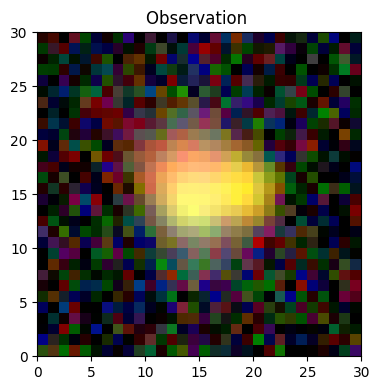

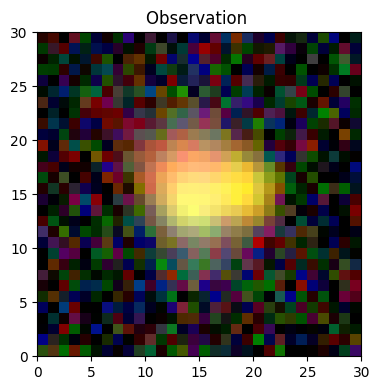

In [5]:
# 1. Initialize lists to hold the stacks (just like the tutorial)
rgb_data = []
rgb_weights = []
rgb_psfs = []
rgb_channels = []
rgb_wcs = None

# 2. Pick one epoch to look at (e.g., the first one in your 'times' list)
target_epoch = times[8] 

for band in ['g', 'r', 'i']: # Standard RGB bands
    data_file_name = f'image_LSST_{band}_{img_index}_SNnoise_{target_epoch}.0.fits'
    img_path = data_path + data_file_name
    
    with fits.open(img_path) as hdul:
        # Save the WCS from the first band (r-band is usually best for the grid)
        if band == 'g':
            rgb_wcs = WCS(hdul[0].header)
            
        # Raw data (2D)
        d = hdul[0].data.astype('float32')
        rgb_data.append(d)
        
        # Calculate weights (using your existing noise function)
        params = telescope_params['LSST']
        noise_sigma = gaussian_noise_sigma(
            image=d,
            readout_noise=params['read_noise'],
            exposure_time=params['exposure_time'][band],
            sky_brightness=params['sky_brightness_mags'][band],
            pixel_scale=params['pixel_scale'],
            num_exposures=params['num_exposures'][band],
            magnitude_zero_point=params['zero_points_mags'][band]
        )
        rgb_weights.append(np.ones_like(d) / (noise_sigma**2))
        
        # PSF
        rgb_psf_data = np.load(psf_path + f'caustics_gaussian_psf_LSST_{band}_size_17.npy')
        rgb_psf_norm = rgb_psf_data.astype('float32') / np.sum(rgb_psf_data)
        rgb_psfs.append(scarlet2.ArrayPSF(jnp.array(rgb_psf_norm)))
        
        # Channel label
        rgb_channels.append((band, target_epoch))

# 3. Create ONE single Observation (The Tutorial Way)
# This stacks the lists into a (3, Y, X) cube automatically
rgb_combined_obs = scarlet2.Observation(
    jnp.array(rgb_data),
    weights=jnp.array(rgb_weights),
    psf=rgb_psfs[0],
    wcs=rgb_wcs,
    channels=rgb_channels
)

# 4. Now the plotter will be happy!
norm = scarlet2.plot.AsinhAutomaticNorm(rgb_combined_obs)
scarlet2.plot.observation(rgb_combined_obs, norm=norm, add_labels=False, show_psf=False)

In [6]:
# ============================================================================
# 3. Load Observations for each Rubin epoch
# ============================================================================
for ind_b, band in enumerate(bands):
    for ind_t, epoch in enumerate(times):
        channel_sc2 = (band, int(ind_t)) 

        if epoch == t_on:
            ind_t_on = str(ind_t)
        elif epoch == t_off:
            ind_t_off = str(ind_t)
        
        # get channels for only 'on' times
        if epoch >= t_start and epoch <t_end:  
            channels_on.append(channel_sc2)
            epochs_on.append(int(ind_t))
        
        # Caustics image simulation files (fits)
        data_file_name = 'image_LSST_'+band+'_'+str(img_index)+'_SNnoise_'+str(epoch)+'.0.fits' 
        img = data_path+ data_file_name

        obs_hdu = fits.open(img)
        data_lsst = obs_hdu[0].data
        data_lsst = data_lsst.astype(data_lsst.dtype.newbyteorder('=')) ## Do I sill need this?
        N1, N2 = data_lsst.shape
        data_lsst = data_lsst.reshape(1, N1, N2) #reshape because?

        # WCS - saved as headerof fits files, made manually in Caustics
        wcs_lsst = WCS(obs_hdu[0].header)

        # PSF data - npy files with gaussians, made manually in Caustics
        psf_data = np.load(psf_path + f'caustics_gaussian_psf_LSST_{band}_size_17.npy')
        psf_jax = jnp.asarray([psf_data.astype('float32')]/np.sum(psf_data.astype('float32')))
        psf_lsst = scarlet2.ArrayPSF(psf_jax)

        
        ## Recalculate added noise (added on top of Caustics image before saving .fits files)
        params = telescope_params['LSST']
        noise_sigma = gaussian_noise_sigma(
            image = data_lsst,
            readout_noise = params['read_noise'],
            exposure_time = params['exposure_time'][band],
            sky_brightness = params['sky_brightness_mags'][band],
            pixel_scale = params['pixel_scale'],
            num_exposures = params['num_exposures'][band],
            magnitude_zero_point = params['zero_points_mags'][band]
        )
        weights_lsst = jnp.ones_like(data_lsst) / (noise_sigma**2)
        # print(noise_sigma)
       
        # Make observation
        obs_lsst = scarlet2.Observation(jnp.asarray(data_lsst),
                                      wcs=wcs_lsst,
                                      psf=psf_lsst,
                                      channels=[channel_sc2],
                                      weights=weights_lsst)
        observations.append(obs_lsst)
        channels.append(channel_sc2)


In [7]:
print(wcs_lsst)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 15.5 15.5 
PC1_1 PC1_2  : -5.5555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 5.5555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 30  30


In [8]:
# ============================================================================
# 5. Load high-res off/on images for Roman
# ============================================================================

#Read in a single epoch of high resolution imaging WITHOUT the SN
for ind_b, (band, BAND) in enumerate(zip(bands, BANDS)):

    channel_sc2 = (BAND, int(ind_t_off))
    epoch = t_off
    
    data_file_name = 'image_Roman_'+BAND+'_'+str(img_index)+'_SNnoise_'+str(t_off)+'.0.fits' 
    img = data_path+ data_file_name

    obs_hdu = fits.open(img)
    data_roman = obs_hdu[0].data
    data_roman = data_roman.astype(data_roman.dtype.newbyteorder('=')) ## Do I sill need this?
    N1, N2 = data_roman.shape
    data_roman = data_roman.reshape(1, N1, N2) #reshape because?
    wcs_roman = WCS(obs_hdu[0].header)

    psf_data = np.load(psf_path + f'caustics_gaussian_psf_Roman_{BAND}_size_17{psf_version}.npy')
    psf_jax = jnp.asarray([psf_data.astype('float32')]/np.sum(psf_data.astype('float32')))
    psf_roman = scarlet2.ArrayPSF(psf_jax)

    ## Recalculate added noise
    params = telescope_params['Roman']
    noise_sigma = gaussian_noise_sigma(
        image = data_roman,
        readout_noise = params['read_noise'],
        exposure_time = params['exposure_time'][BAND],
        sky_brightness = params['sky_brightness_mags'][BAND],
        pixel_scale = params['pixel_scale'],
        num_exposures = params['num_exposures'][BAND],
        magnitude_zero_point = params['zero_points_mags'][BAND]
    )
    weights_roman = jnp.ones_like(data_roman) / (noise_sigma**2)
    print(noise_sigma)

    # define two observation packages and match to frame
    obs_roman_offSN = scarlet2.Observation(data_roman,
                                   wcs=wcs_roman,
                                   psf=psf_roman,
                                   channels=[channel_sc2],
                                   weights= weights_roman) #should weights be none?    
    
    channels.append(channel_sc2)
    observations.append(obs_roman_offSN)



#Read in a single epoch of high resolution imaging WITH the SN
if n_roman_epochs == 2:
    for ind_b, (band, BAND) in enumerate(zip(bands, BANDS)):
        
        channel_sc2 = (BAND, int(ind_t_on))
        epoch = t_on
        
        data_file_name = 'image_Roman_'+BAND+'_'+str(img_index)+'_SNnoise_'+str(t_on)+'.0.fits' 
        img = data_path+ data_file_name
    
        obs_hdu = fits.open(img)
        data_roman = obs_hdu[0].data
        data_roman = data_roman.astype(data_roman.dtype.newbyteorder('=')) ## Do I sill need this?
        N1, N2 = data_roman.shape
        data_roman = data_roman.reshape(1, N1, N2) #reshape because?
        wcs_roman = WCS(obs_hdu[0].header)
        print(wcs_roman)
        # data_roman_offSN = jnp.array(np.asarray(data_roman,dtype=float), jnp.float32)
    
        psf_data = np.load(psf_path + f'caustics_gaussian_psf_Roman_{BAND}_size_17{psf_version}.npy')
        psf_jax = jnp.asarray([psf_data.astype('float32')]/np.sum(psf_data.astype('float32')))
        psf_roman = scarlet2.ArrayPSF(psf_jax)
        print(np.sum(psf_roman))
        ## Recalculate added noise
        params = telescope_params['Roman']
        noise_sigma = gaussian_noise_sigma(
            image = data_roman,
            readout_noise = params['read_noise'],
            exposure_time = params['exposure_time'][BAND],
            sky_brightness = params['sky_brightness_mags'][BAND],
            pixel_scale = params['pixel_scale'],
            num_exposures = params['num_exposures'][BAND],
            magnitude_zero_point = params['zero_points_mags'][BAND]
        )
        weights_roman = jnp.ones_like(data_roman) / (noise_sigma**2)
        print(noise_sigma)
        
    
        channels_on.append(channel_sc2)
        epochs_on.append(int(ind_t_on))
        
        # define two observation packages and match to frame
        obs_roman_postSN = scarlet2.Observation(jnp.asarray(data_roman),
                                       wcs=wcs_roman,
                                       psf=psf_roman,
                                       channels=[channel_sc2],
                                       weights=weights_roman) #should weights be none? 
        
        channels.append(channel_sc2)
        observations.append(obs_roman_postSN)


0.17159469598490368
0.11027849283278497
0.06017137680885486


In [9]:
#How many observations did we end up reading in? Should be at least a few
print(len(observations))
print(channels)
bandind = np.unique([x[0] for x in channels],return_index=True)

print(bandind[1])


51
[('g', 0), ('g', 1), ('g', 2), ('g', 3), ('g', 4), ('g', 5), ('g', 6), ('g', 7), ('g', 8), ('g', 9), ('g', 10), ('g', 11), ('g', 12), ('g', 13), ('g', 14), ('g', 15), ('r', 0), ('r', 1), ('r', 2), ('r', 3), ('r', 4), ('r', 5), ('r', 6), ('r', 7), ('r', 8), ('r', 9), ('r', 10), ('r', 11), ('r', 12), ('r', 13), ('r', 14), ('r', 15), ('i', 0), ('i', 1), ('i', 2), ('i', 3), ('i', 4), ('i', 5), ('i', 6), ('i', 7), ('i', 8), ('i', 9), ('i', 10), ('i', 11), ('i', 12), ('i', 13), ('i', 14), ('i', 15), ('f106', 0), ('f129', 0), ('f158', 0)]
[48 49 50  0 32 16]


In [10]:
# ============================================================================
# 6. Make Frame and match observations
# ============================================================================
# model_frame_psf = scarlet2.GaussianPSF(0.7)
model_frame = scarlet2.Frame.from_observations(
    observations=observations,
    coverage="union"  # or "intersection"
    )

for obs in observations:
    obs.match(model_frame)

### Find Sources

In [11]:
# ============================================================================
# 7. Find sourced in image - from RubinRoman_TD notebook
# ============================================================================

def makeCatalog(observations, lvl=3, wave=True, SNR=2.0):
    
    normed_images = np.asarray([obs.data[0] for obs in observations])
    interps = normed_images
    
    interps = np.asarray(interps/np.sum(interps))
    detect_image = np.sum(interps,axis=(0))
    # Wavelet transform
    # wave_detect = scarlet.Starlet.from_image(detect_image).coefficients
    wave_detect = Starlet.from_image(detect_image).coefficients

    if wave:
        # Creates detection from the first 3 wavelet levels
        detect = wave_detect[:lvl,:,:].sum(axis = 0)
    else:
        detect = detect_image

    detect = np.array(detect)

    # Runs SEP detection
    bkg = sep.Background(detect)
    catalog = sep.extract(detect-bkg.globalback, SNR, err=bkg.globalrms)
    background=[]
    bg_rms=[]
    for ind in range(len(observations)):
        img = copy.copy(np.asarray(observations[ind].data))
        if np.size(img.shape) == 3:
            bg_rms.append(np.array([sep.Background(band).globalrms for band in img]))
            background.append(np.array([sep.Background(band).globalback for band in img]))
        else:
            bg_rms.append(sep.Background(img).globalrms)
            background.append(sep.Background(img).globalback)
    return catalog, bg_rms, detect_image, background

In [12]:
# ============================================================================
# 8. Find sources in image - from RubinRoman_TD notebook
# USE ROMAN IMAGES ONLY
# ============================================================================

#If the source detection is not finding all the sources, you can first try to adjust these three parameters to help it find the sources
lvl=2
wave=2
SNR=5.0  # was 2

lsst_obs = observations[:-n_roman]
roman_obs = observations[-n_roman:]

observations_sc2=[]
normsingle=[]

# ============================================================================   
# DETECT SOURCES BASED ONLY ON ROMAN IMGS

catalog_single_roman, bgsingle_roman, detectsingle_roman, globalback_roman = makeCatalog(roman_obs, lvl, wave, SNR)
pixel = np.stack((catalog_single_roman['y'], catalog_single_roman['x']), axis=1)
ra_dec = pixel
print(ra_dec.shape)
# ============================================================================

(3, 2)


In [13]:
#################################################################################
### MAKE observations_sc2 ###########################

bgarr_roman     = np.asarray(bgsingle_roman)
bgarrall_roman  = np.hstack((bgarr_roman.flatten(),np.asarray(bgsingle_roman).flatten()))
bgarr_roman     = np.asarray(bgsingle_roman)
print(bgarrall_roman.shape)

catalog_single_lsst, bgsingle_lsst, detectsingle_lsst, globalback_lsst = makeCatalog(lsst_obs, lvl, wave, SNR)
bgarr_lsst    = np.asarray(bgsingle_lsst)
bgarrall_lsst = np.hstack((bgarr_lsst.flatten(),np.asarray(bgsingle_lsst).flatten()))
bgarr_lsst    = np.asarray(bgsingle_lsst)
print(bgarrall_lsst.shape)


bgr_lsst = np.array([b[0] for b in bgarr_lsst])
bgr_roman = np.array([b[0] for b in bgarr_roman])
bgarr_all = np.concatenate([bgr_lsst, bgr_roman], axis=0)

gb_lsst = np.array([b[0] for b in globalback_lsst])
gb_roman = np.array([b[0] for b in globalback_roman])
globalback_all = np.concatenate([gb_lsst, gb_roman], axis=0)

print(len(bgarr_all))
print(len(globalback_all))


for ind,(obs2, bg, back) in enumerate(zip(observations, bgarr_all, globalback_all)):

    print(ind)
    
    w = obs2.frame.wcs
    psf = obs2.frame.psf
    weights2=np.ones(obs2.data.shape) / (bg**2)#[:, None, None]  #??in RubinRoman notebook insteads of bg it uses bgarr_all, is this a typo?
    data = obs2.data-back   #Subtract background flux

    print(channels[ind])
    
    obs_sc2 = scarlet2.Observation(jnp.asarray(data), jnp.asarray(weights2), psf=psf,channels=[channels[ind]],wcs=w)
    observations_sc2.append(obs_sc2)
    # print("obs2.data shape:", obs2.data.shape, '\n')
    # print('obs2.data: ', obs2.data, '\n')
    # print('obs2.data[:,10:-10,10:-10]:', obs2.data[:,10:-10,10:-10], '\n')

    
    #Store norm based on observation data
    normsingle.append(
        AsinhPercentileNorm(
            jnp.asarray(np.asarray((obs2.data[:,10:-10,10:-10]),dtype=np.float32)),
            percentiles=[0.001, 50, 80])
    )



(6,)
(96,)
51
51
0
('g', 0)
1
('g', 1)
2
('g', 2)
3
('g', 3)
4
('g', 4)
5
('g', 5)
6
('g', 6)
7
('g', 7)
8
('g', 8)
9
('g', 9)
10
('g', 10)
11
('g', 11)
12
('g', 12)
13
('g', 13)
14
('g', 14)
15
('g', 15)
16
('r', 0)
17
('r', 1)
18
('r', 2)
19
('r', 3)
20
('r', 4)
21
('r', 5)
22
('r', 6)
23
('r', 7)
24
('r', 8)
25
('r', 9)
26
('r', 10)
27
('r', 11)
28
('r', 12)
29
('r', 13)
30
('r', 14)
31
('r', 15)
32
('i', 0)
33
('i', 1)
34
('i', 2)
35
('i', 3)
36
('i', 4)
37
('i', 5)
38
('i', 6)
39
('i', 7)
40
('i', 8)
41
('i', 9)
42
('i', 10)
43
('i', 11)
44
('i', 12)
45
('i', 13)
46
('i', 14)
47
('i', 15)
48
('f106', 0)
49
('f129', 0)
50
('f158', 0)


In [14]:
# ## Debugging inhomogeneous part
# for i, obs in enumerate(observations):
#     print(f"Index {i} -> obs.data[0] shape: {obs.data[0].shape}")

In [15]:
model_frame = scarlet2.Frame.from_observations(
    observations=observations_sc2,
    model_psf = scarlet2.GaussianPSF(sigma = 0.3),
    coverage="union",  # or "intersection"
)

In [16]:
print(model_frame)

wcs_roman_oversampled = copy.deepcopy(model_frame.wcs)
wcs_roman_oversampled.wcs.crpix = model_frame.wcs.wcs.crpix*oversamplefactor 
wcs_roman_oversampled.wcs.pc = model_frame.wcs.wcs.pc/oversamplefactor 
wcs_roman_oversampled._naxis[-1] = model_frame.wcs._naxis[-1]*oversamplefactor
wcs_roman_oversampled._naxis[-2] = model_frame.wcs._naxis[-2]*oversamplefactor

bbox_roman_oversampled = copy.deepcopy(model_frame.bbox)
# bbox_roman_oversampled.shape = (bbox_roman_oversampled.shape[-3],bbox_roman_oversampled.shape[-2]*oversamplefactor,bbox_roman_oversampled.shape[-1]*oversamplefactor)

#print(wcs_roman_oversampled)
object.__setattr__(model_frame,'wcs', wcs_roman_oversampled)
object.__setattr__(model_frame,'bbox', bbox_roman_oversampled)
print(model_frame)

norm_corr = []
for i, obs in enumerate(observations_sc2):
    # if i<n_lsst:
    obs_corr = scarlet2.CorrelatedObservation.from_observation(obs,resample_to_frame=model_frame)#,resample_psf=True)
    # else:
    #     obs_corr = scarlet2.CorrelatedObservation.from_observation(obs,resample_to_frame=model_frame,resample_psf=False,lanczos_order=21)

    norm_c= scarlet2.plot.AsinhAutomaticNorm(obs_corr)
    norm_corr.append(norm_c)
    
    obs_corr.match(model_frame)
    observations_sc2[i] = obs_corr

Frame(
  bbox=Box(shape=(51, 55, 55), origin=(0, 0, 0)),
  psf=GaussianPSF(morphology=GaussianMorphology(size=0.3, ellipticity=None)),
  wcs=WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 28.0 28.0 
PC1_1 PC1_2  : -3.0555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 3.0555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 55  55,
  channels=[
    ('g', 0),
    ('g', 1),
    ('g', 2),
    ('g', 3),
    ('g', 4),
    ('g', 5),
    ('g', 6),
    ('g', 7),
    ('g', 8),
    ('g', 9),
    ('g', 10),
    ('g', 11),
    ('g', 12),
    ('g', 13),
    ('g', 14),
    ('g', 15),
    ('r', 0),
    ('r', 1),
    ('r', 2),
    ('r', 3),
    ('r', 4),
    ('r', 5),
    ('r', 6),
    ('r', 7),
    ('r', 8),
    ('r', 9),
    ('r', 10),
    ('r', 11),
    ('r', 12),
    ('r', 13),
    ('r', 14),
    ('r', 15),
    ('i', 0),
    ('i', 1),
    ('i', 2),
    ('i', 3),
    ('i', 4),
    ('i', 5),
    ('i', 6),
    ('i', 7),
    ('i', 8),
    ('i', 9),
    ('i', 10),
    ('i', 11),

### Initialize Sources

In [17]:
# ============================================================================
# 10. Source initialization
# ============================================================================
lsst_obs_sc2 = observations_sc2[:-n_roman]
roman_obs_sc2 = observations_sc2[-n_roman:]

band_selector  = lambda ch: ch[0]
epoch_selector = lambda ch: ch[1]


In [18]:
# ============================================================================
# 9. Get and visualize sources in image
# ============================================================================
world_coords = []
for y, x in ra_dec:
    sky = wcs_roman.pixel_to_world(x, y)   # note: pixel_to_world(x, y)
    world_coords.append(SkyCoord(sky.ra, sky.dec))

roman_pixel_coords = [wcs_roman.world_to_pixel(sky) for sky in world_coords]
lsst_pixel_coords = [wcs_lsst.world_to_pixel(sky) for sky in world_coords]

## Ra and dec centers from SEP catalog
sky_coords_ = world_coords

In [19]:
print("Detected source pixel coordinates:")
for i, (y, x) in enumerate(ra_dec, start=1):
    print(f"  Source {i:>2d}: x = {x:.2f}, y = {y:.2f}")

print("\nDetected source sky coordinates:")
for i, sky in enumerate(world_coords, start=1):
    # in decimal degrees:
    print(f"  Source {i:>2d}: RA = {sky.ra.deg:.6f}°,  Dec = {sky.dec.deg:.6f}°")

print("\nBack to LSST pixel coords:")
for i, (x_lsst, y_lsst) in enumerate(lsst_pixel_coords, start=1):
    print(f" Source {i}:  x = {x_lsst:.2f},  y = {y_lsst:.2f}")

print("\nBack to Roman pixel coords:")
for i, (x_roman, y_roman) in enumerate(roman_pixel_coords, start=1):
    print(f" Source {i}:  x = {x_roman:.2f},  y = {y_roman:.2f}")


Detected source pixel coordinates:
  Source  1: x = 23.87, y = 30.17
  Source  2: x = 28.18, y = 30.65
  Source  3: x = 26.97, y = 26.75

Detected source sky coordinates:
  Source  1: RA = 0.000096°,  Dec = 0.000097°
  Source  2: RA = 359.999964°,  Dec = 0.000112°
  Source  3: RA = 0.000001°,  Dec = -0.000008°

Back to LSST pixel coords:
 Source 1:  x = 12.78,  y = 16.24
 Source 2:  x = 15.15,  y = 16.51
 Source 3:  x = 14.48,  y = 14.36

Back to Roman pixel coords:
 Source 1:  x = 23.87,  y = 30.17
 Source 2:  x = 28.18,  y = 30.65
 Source 3:  x = 26.97,  y = 26.75


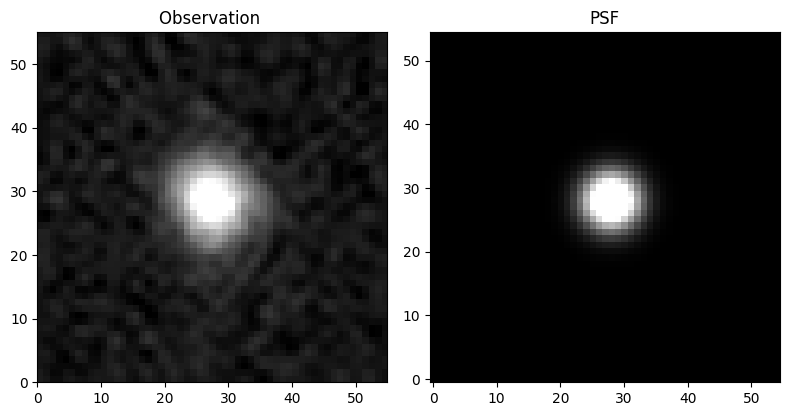

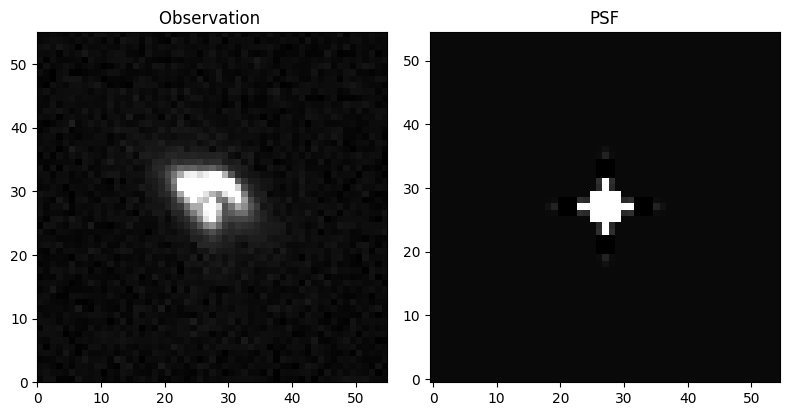

"\n# get current axis\nax = plt.gca()\n\n# loop over sources and draw both red circle and index label\nfor i, (x0, y0) in enumerate(roman_pixel_coords):\n    x0, y0 = float(x0), float(y0)\n\n    # Draw red circle\n    ax.scatter(\n        x0, y0,\n        s=80,\n        edgecolors='red',\n        facecolors='none',\n        linewidths=2\n    )\n\n    # Add index label\n    ax.text(\n        x0, y0,\n        str(i),\n        color='red',\n        fontsize=5,\n        ha='center',\n        va='center',\n        weight='bold'\n    )\n\nplt.show()\n"

In [20]:
# draw the observation into the current axes
lsst_obs_sc2 = observations_sc2[:-n_roman]
roman_obs_sc2 = observations_sc2[-n_roman:]

scarlet2.plot.observation(
    observation=observations_sc2[1],
    norm=None,
    channel_map=None,
    show_psf=True,
    add_labels=False,
)
# save_path = f'{img_index}_results/{date}/sc2_prefitting/'
# plt.savefig(save_path+ str(img_index)+'_observation_lsst'+version+'.png')
plt.show()


scarlet2.plot.observation(
    observation=observations_sc2[50],
    norm=None,
    channel_map=None,
    show_psf=True,
    add_labels=False,
)
# save_path = f'{img_index}_results/{date}/sc2_prefitting/'
# plt.savefig(save_path+ str(img_index)+'_observation_roman'+version+'.png')
plt.show()

#plt.imshow(np.log(observations[53].frame.psf()[0]))
#plt.show()
'''
# get current axis
ax = plt.gca()

# loop over sources and draw both red circle and index label
for i, (x0, y0) in enumerate(roman_pixel_coords):
    x0, y0 = float(x0), float(y0)

    # Draw red circle
    ax.scatter(
        x0, y0,
        s=80,
        edgecolors='red',
        facecolors='none',
        linewidths=2
    )

    # Add index label
    ax.text(
        x0, y0,
        str(i),
        color='red',
        fontsize=5,
        ha='center',
        va='center',
        weight='bold'
    )

plt.show()
'''

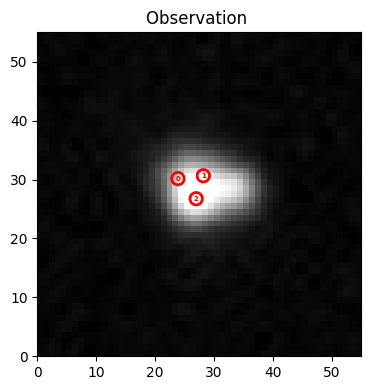

In [21]:
scarlet2.plot.observation(
    observation=observations_sc2[40],
    norm=None,
    channel_map=None,
    show_psf=False,
    add_labels=False,
)
#plt.imshow(np.log(observations[53].frame.psf()[0]))
#plt.show()
# get current axis
ax = plt.gca()

# loop over sources and draw both red circle and index label
for i, (x0, y0) in enumerate(roman_pixel_coords):
    x0, y0 = float(x0), float(y0)

    # Draw red circle
    ax.scatter(
        x0, y0,
        s=80,
        edgecolors='red',
        facecolors='none',
        linewidths=2
    )

    # Add index label
    ax.text(
        x0, y0,
        str(i),
        color='red',
        fontsize=5,
        ha='center',
        va='center',
        weight='bold'
    )

plt.show()


In [22]:
# ## Debugging inhomogeneous part
# for i, obs in enumerate(observations):
#     print(f"Index {i} -> obs.data[0] shape: {obs.data[0].shape}")

In [23]:
# ============================================================================
# 10.2 Get coords of source in center of image (assume it is the lens)
# ============================================================================

'''
Modify sources based on system
--> adapt list sky_coords
--> adapt is extended
'''

#### Check if in center of image:
_, H, W   = lsst_obs_sc2[0].data.shape               # data.shape = (C, H, WT
center_pix = np.array([W//2, H//2], dtype=int)        # [x_center, y_center] in Roman coords
tol_pix    = 3                                        # how close (in px) counts as “at centre”
is_center = []
center_pix_sky = wcs_roman.pixel_to_world(center_pix[0], center_pix[1])
center_pix_sky_coords = SkyCoord(center_pix_sky.ra, center_pix_sky.dec)
print(center_pix, '\n')
print(sky_coords_, '\n')

sky_coords = sky_coords_


#17462 #96679 #1952
if img_index == 96679:
    del sky_coords[1]
    lsst_source_2_x = center_pix[0] + 0.2
    lsst_source_2_y = center_pix[1]
    new_sky_coord_2 = wcs_roman.pixel_to_world(lsst_source_2_x, lsst_source_2_y)

    lsst_source_3_x = center_pix[0] - 0.2
    lsst_source_3_y = center_pix[1] 
    new_sky_coord_3 = wcs_roman.pixel_to_world(lsst_source_3_x, lsst_source_3_y)

    sky_coords = sky_coords + [new_sky_coord_2, new_sky_coord_3]
    is_extended = [True, True, False, False]
    lens_indx = 1

elif img_index == 209546:
    lsst_source_1_x = center_pix[0] 
    lsst_source_1_y = center_pix[1] - 3
    new_sky_coord_1 = wcs_roman.pixel_to_world(lsst_source_1_x, lsst_source_1_y)
    lsst_source_2_x = center_pix[0] + 0.2
    lsst_source_2_y = center_pix[1]
    new_sky_coord_2 = wcs_roman.pixel_to_world(lsst_source_2_x, lsst_source_2_y)
    lsst_source_3_x = center_pix[0] - 0.2
    lsst_source_3_y = center_pix[1] 
    new_sky_coord_3 = wcs_roman.pixel_to_world(lsst_source_3_x, lsst_source_3_y)
    
    sky_coords = sky_coords + [new_sky_coord_1, new_sky_coord_2, new_sky_coord_3]
    is_extended = [True, True, False, False]
    lens_indx = 0


elif img_index == 2737:
    del sky_coords[0]
    lsst_source_2_x = center_pix[0] + 2
    lsst_source_2_y = center_pix[1] + 21
    new_sky_coord_2 = wcs_roman.pixel_to_world(lsst_source_2_x, lsst_source_2_y)
    lsst_source_3_x = center_pix[0] - 2
    lsst_source_3_y = center_pix[1] - 7
    new_sky_coord_3 = wcs_roman.pixel_to_world(lsst_source_3_x, lsst_source_3_y)
    
    sky_coords = sky_coords + [new_sky_coord_2, new_sky_coord_3]
    is_extended = [True, True, False, False]
    lens_indx = 0

elif img_index == 170330:
    new_source_pixel_x_2 = center_pix[0] + 8
    new_source_pixel_y_2 = center_pix[1] + 1
    new_sky_coord_2 = wcs_roman.pixel_to_world(new_source_pixel_x_2, new_source_pixel_y_2)
    new_source_pixel_x_3 = center_pix[0] - 18
    new_source_pixel_y_3 = center_pix[1] - 6
    new_sky_coord_3 = wcs_roman.pixel_to_world(new_source_pixel_x_3, new_source_pixel_y_3)
    sky_coords = sky_coords + [new_sky_coord_2, new_sky_coord_3] # add PS at same location as 3rd source ie lens
    is_extended = [True, True, False, False]
    lens_indx = 1
elif img_index == 111827:
    sky_coords = sky_coords + [sky_coords[0], sky_coords[1]] # add PS at same location as 3rd source ie lens
    is_extended = [True, True, False, False]
    lens_indx = 0




elif img_index == 216276:
    sky_coords = sky_coords + [sky_coords[0], sky_coords[1]] # add PS at same location as 3rd source ie lens
    is_extended = [True, True, False, False]
    lens_indx = 1



else:
    lsst_source_2_x = center_pix[0] + 0.2
    lsst_source_2_y = center_pix[1] 
    new_sky_coord_2 = wcs_roman.pixel_to_world(lsst_source_2_x, lsst_source_2_y)
    lsst_source_3_x = center_pix[0] - 0.2
    lsst_source_3_y = center_pix[1] 
    new_sky_coord_3 = wcs_roman.pixel_to_world(lsst_source_3_x, lsst_source_3_y)
    
    sky_coords = sky_coords + [new_sky_coord_2, new_sky_coord_3]
    is_extended = [True, True, False, False]
    if img_index==111827:
        lens_indx = 0
    lens_indx = 1

    
        
    

print(sky_coords, '\n')
for i, sky_coord in enumerate(sky_coords):
    print(f"Source {i} at pixel {wcs_lsst.world_to_pixel(sky_coord)}")

print(is_extended)
    

[27 27] 

[<SkyCoord (ICRS): (ra, dec) in deg
    (9.55170756e-05, 9.67809245e-05)>, <SkyCoord (ICRS): (ra, dec) in deg
    (359.99996384, 0.00011159)>, <SkyCoord (ICRS): (ra, dec) in deg
    (8.38444296e-07, -7.56350609e-06)>] 

[<SkyCoord (ICRS): (ra, dec) in deg
    (9.55170756e-05, 9.67809245e-05)>, <SkyCoord (ICRS): (ra, dec) in deg
    (8.38444296e-07, -7.56350609e-06)>, <SkyCoord (ICRS): (ra, dec) in deg
    (359.99999389, 3.50835353e-15)>, <SkyCoord (ICRS): (ra, dec) in deg
    (6.11111111e-06, 3.50835502e-15)>] 

Source 0 at pixel (array(12.78069264), array(16.24205664))
Source 1 at pixel (array(14.484908), array(14.36385689))
Source 2 at pixel (array(14.61), array(14.5))
Source 3 at pixel (array(14.39), array(14.5))
[True, True, False, False]


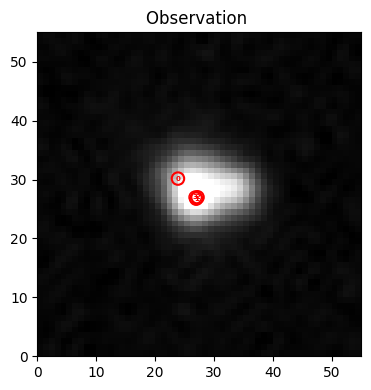

In [24]:
scarlet2.plot.observation(
    observation=observations_sc2[40],
    norm=None,
    channel_map=None,
    show_psf=False,
    add_labels=False,
)

# get current axis
ax = plt.gca()

# # loop over sources and draw both red circle and index label
for i, sky_coord_i in enumerate(sky_coords):
    x0, y0 = wcs_roman.world_to_pixel(sky_coord_i)
    x0, y0 = float(x0), float(y0)

    # Draw red circle
    if i ==3:
        ax.scatter(
            x0, y0,
            s=80,
            edgecolors='red',
            facecolors='none',
            linewidths=1
    )
    else:  
        ax.scatter(
            x0, y0,
            s=80,
            edgecolors='red',
            facecolors='none',
            linewidths=1.5
        )

    # Add index label
    if i ==3:
        ax.text(
            x0, y0,
            str(i),
            color='red',
            fontsize=5,
            ha='center',
            va='center',
            weight='bold'
        )
    else:
        ax.text(
            x0, y0,
            str(i),
            color='red',
            fontsize=5,
            ha='center',
            va='center',
            weight='bold'
        )

# save_path = f'{img_index}_results/{date}/sc2_prefitting/'
# plt.savefig(save_path+ str(img_index)+'_source_detection_lsst'+version+'.png')
plt.show()

In [25]:
print(channels)
# print(epochs)
print(channels_on)
print(bandind)

[('g', 0), ('g', 1), ('g', 2), ('g', 3), ('g', 4), ('g', 5), ('g', 6), ('g', 7), ('g', 8), ('g', 9), ('g', 10), ('g', 11), ('g', 12), ('g', 13), ('g', 14), ('g', 15), ('r', 0), ('r', 1), ('r', 2), ('r', 3), ('r', 4), ('r', 5), ('r', 6), ('r', 7), ('r', 8), ('r', 9), ('r', 10), ('r', 11), ('r', 12), ('r', 13), ('r', 14), ('r', 15), ('i', 0), ('i', 1), ('i', 2), ('i', 3), ('i', 4), ('i', 5), ('i', 6), ('i', 7), ('i', 8), ('i', 9), ('i', 10), ('i', 11), ('i', 12), ('i', 13), ('i', 14), ('i', 15), ('f106', 0), ('f129', 0), ('f158', 0)]
[('g', 1), ('g', 2), ('g', 3), ('g', 4), ('g', 5), ('g', 6), ('g', 7), ('g', 8), ('g', 9), ('g', 10), ('g', 11), ('g', 12), ('g', 13), ('r', 1), ('r', 2), ('r', 3), ('r', 4), ('r', 5), ('r', 6), ('r', 7), ('r', 8), ('r', 9), ('r', 10), ('r', 11), ('r', 12), ('r', 13), ('i', 1), ('i', 2), ('i', 3), ('i', 4), ('i', 5), ('i', 6), ('i', 7), ('i', 8), ('i', 9), ('i', 10), ('i', 11), ('i', 12), ('i', 13)]
(array(['f106', 'f129', 'f158', 'g', 'i', 'r'], dtype='<U4'

In [26]:
def gaus2d(x=0, y=0, mx=0, my=0, sx=1, sy=1):
    return 1. / (2. * np.pi * sx * sy) * np.exp(-((x - mx)**2. / (2. * sx**2.) + (y - my)**2. / (2. * sy**2.)))

In [79]:
# ============================================================================
# 10.3 Source initialization (point vs extended + Gaussian‐moment sizes)
# ============================================================================
## Build the Scarlet Scene with one Source per detection


with Scene(model_frame) as scene:
    for i, coords  in enumerate(sky_coords):

        ##############################################################        
        ##############################################################
        ## EXTENDED SOURCE (e.g. host galaxy) 
        if is_extended[i]:
            print(f"Source {i}: EXTENDED ")
            if i == lens_indx: 
                print('lens')
            else:
                print('host')
            try: 
                print('trying from_gaussian_moments')
                x0_roman, y0_roman = wcs_roman_oversampled.world_to_pixel(coords)
                x0_roman, y0_roman = float(x0_roman), float(y0_roman)
                spectrum_roman, morphology_roman = init.from_gaussian_moments(
                    roman_obs_sc2, 
                    coords,
                    min_snr = 4
                )

                morphology = morphology_roman
                
                
            ## Use compact_morphology if gaussian moments fails
            except IndexError:
                print('Using gaus2d')
                if i == lens_indx:
                    if img_index == 96679:  #added lens box
                        x = np.linspace(-20, 20, 40)
                        y = np.linspace(-20, 20, 40)
                        x, y = np.meshgrid(x, y) # get 2D variables instead of 1D
                        morphology = gaus2d(x, y, sx=1.5,sy=1.5)  
                        
                else:
                    if img_index == 96679:
                        x = np.linspace(-20, 20, 40)
                        y = np.linspace(-20, 20, 40)
                        x, y = np.meshgrid(x, y) # get 2D variables instead of 1D
                        morphology = gaus2d(x, y, sx=5, sy=5)

            try:
                x0_lsst, y0_lsst = wcs_lsst.world_to_pixel(coords)
                x0_lsst, y0_lsst = float(x0_lsst), float(y0_lsst)
                spectrum_lsst, morphology_lsst = init.from_gaussian_moments(
                    lsst_obs_sc2, 
                    coords,#(x0_lsst, y0_lsst),
                    min_snr = 5
                )
            except:
                spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)
                #spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)

            
            print('morphology.shape before padding: ', morphology.shape)
            # initialize with  Starlet Array Morphology
            if i == lens_indx:                      #lens
                pad = int((15 - morphology.shape[0])/2)
            else:                                           #host
                pad = int((35 - morphology.shape[0])/2)
            pad = np.clip(pad, a_min=0, a_max = 100)
            morph = np.pad(morphology,(pad, pad), 'constant')
            morph[morph<1e-8]=1e-8
            # morph = scarlet2.StarletMorphology.from_image(morph)
            morph = jnp.asarray(morph)
            
            print('morphology.shape after padding: ', morph.shape)
            
            ## join lsst and roman fluxes
            # fluxes = np.hstack((spectrum_lsst,0.1*spectrum_roman))[:6]#[bandind[1]]
            g_0, r_0, i_0 = spectrum_lsst[0], spectrum_lsst[16], spectrum_lsst[32]   # First 'g'
            f106_0, f129_0, f158_0 = spectrum_roman[0], spectrum_roman[1], spectrum_roman[2]
            # print('Roman flux: ', f106_0, f129_0, f158_0)
            fluxes = np.array([g_0, r_0, i_0, 
                                f106_0, f129_0, f158_0])
            fluxes[fluxes<1e-6]=1e-6
            print(fluxes,bandall)
            
            ## Fit StaticArraySpectrum to source
            static_spectrum = scarlet2.StaticArraySpectrum(
                    fluxes,
                    # bands=['g', 'r', 'i', 'G', 'R', 'I'],
                    bands=bandall,
                    band_selector=band_selector
                )  
            scarlet2.Source(coords, static_spectrum, morph)
        
        ########################################################################
        # POINT SOURCE (transient/SN) —
        else:
            print(f"Source {i}: POINT SOURCE")
            spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)  #coords in sky coords ?, include correct_psf ?
            spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)  #coords in sky coords ?, include correct_psf ?
            # the above returns arrays containing fluxes for ALL images, but sets the roman/lsst image fluxes to 0 in spectrum_lsst/roman
            spectrum_lsst = spectrum_lsst[:n_lsst]
            spectrum_roman = spectrum_roman[n_lsst:]
            flux_var = np.hstack((spectrum_lsst, spectrum_roman))
            flux_var[flux_var<1e-6]=np.median(flux_var)  #from RubinRoman_TD
            flux_var[np.isnan(flux_var)]=1e-6 #from RubinRoman_TD

            # Set off epoch flux to 0 (small value)
            for j, (band, epoch) in enumerate(channels):
                if epoch not in epochs_on:
                    flux_var[j] = 1e-10  # Or 0.0
                if epoch in epochs_on:
                    flux_var[j] = flux_var[j]*10  # Or 0.0
    

            # Build mask of al the “off‐SN” channels
            # Set flux for off channels to 1e-20 (almost 0, avoid division w 0 later on)
            # off_mask = [i for i,ch in enumerate(channels) if ch not in channels_on]
            flux = jnp.asarray(flux_var)
            print(flux)
            # off_idx = jnp.array(off_mask, dtype=jnp.int32)
            # flux = flux.at[off_idx].set(1e-20)
            
            transient_spectrum = scarlet2.TransientArraySpectrum(
                    flux,
                    epochs=epochs_on,#epochs, # all epochs or channels_zeroed?
                    epoch_selector=epoch_selector
                )
            scarlet2.PointSource(coords, transient_spectrum)
            

# By now `scene.sources` contains your point/transient sources and extended source(s).
print(scene)


Source 0: EXTENDED 
host
trying from_gaussian_moments
Channel '('g', 0)' not found in observations. Setting amplitude to 0.
Channel '('g', 1)' not found in observations. Setting amplitude to 0.
Channel '('g', 2)' not found in observations. Setting amplitude to 0.
Channel '('g', 3)' not found in observations. Setting amplitude to 0.
Channel '('g', 4)' not found in observations. Setting amplitude to 0.
Channel '('g', 5)' not found in observations. Setting amplitude to 0.
Channel '('g', 6)' not found in observations. Setting amplitude to 0.
Channel '('g', 7)' not found in observations. Setting amplitude to 0.
Channel '('g', 8)' not found in observations. Setting amplitude to 0.
Channel '('g', 9)' not found in observations. Setting amplitude to 0.
Channel '('g', 10)' not found in observations. Setting amplitude to 0.
Channel '('g', 11)' not found in observations. Setting amplitude to 0.
Channel '('g', 12)' not found in observations. Setting amplitude to 0.
Channel '('g', 13)' not found in 

In [80]:
print(epochs_on)
print(scene.sources[0].spectrum.data)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
[9.9965978e-01 1.2925907e+00 1.9544197e+00 1.0000000e-06 1.0000000e-06
 1.0000000e-06]


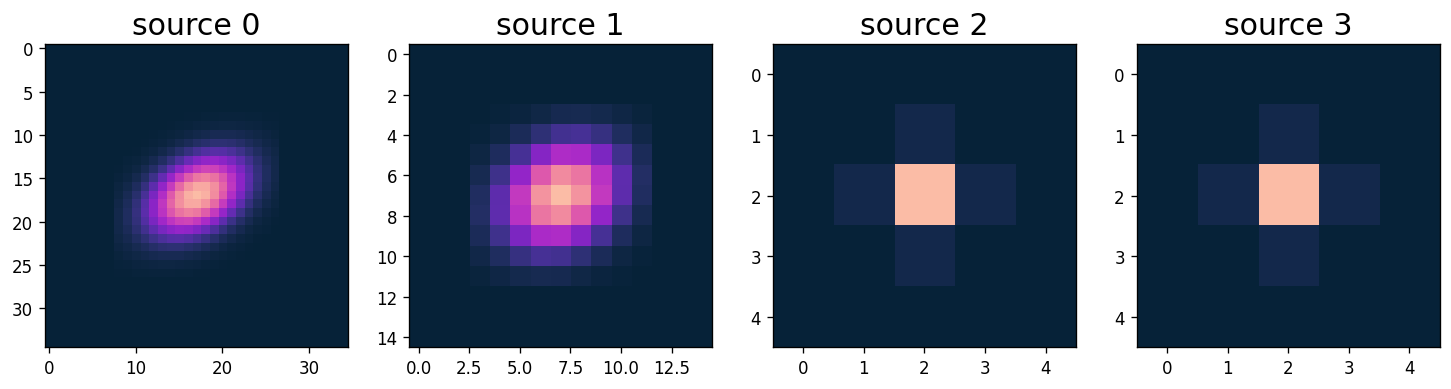

<Figure size 640x480 with 0 Axes>

In [81]:
import cmasher as cmr
cmap = cmr.bubblegum
int_method='none'
fig, axes = plt.subplots(1, len( scene.sources ), figsize=(15,6),dpi=120)
for i, ax in enumerate(axes):
    if is_extended[i]==True:#i!=indtransient:
        y = np.array(scene.sources[i].morphology)
        # y = np.array(scene.sources[i].morphology())
        # should work if it's already 2D or 3D
    else:
        y = scene.sources[i].morphology()
    ax.imshow(y, cmap = cmap,interpolation=int_method)#,vmin = np.max([np.min(np.log(y)[np.log(y)>-15]),-15]))
    ax.set_title(f"source {i}", fontsize = 18)
    ax.invert_yaxis()

additional_path = ''# 'different_separations/small_sep/'
save_path = f'{additional_path}{img_index}_results/{date}/roman_off_epoch/sc2_prefitting/'

plt.savefig(save_path+str(img_index)+'_source_models'+version+'.png')

plt.show()
plt.clf()

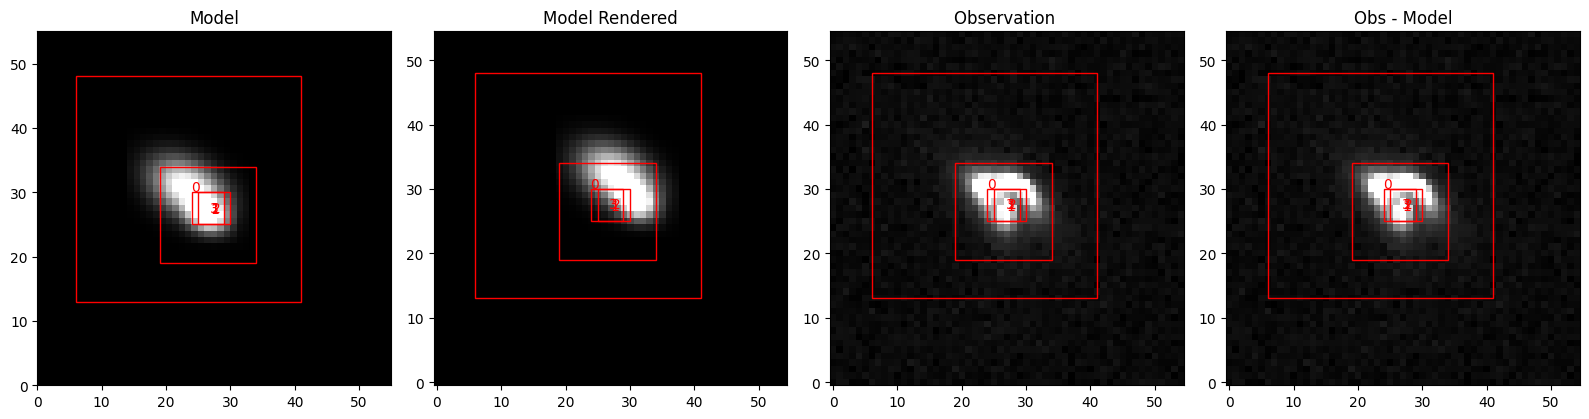

In [82]:
#print(obs_hsc.data.shape,obs_hst.data.shape)
#print(frameall.channels,channels_zeroed)
#print(obs_hsc.render(scene()).shape,obs_hst.render(scene()).shape)
scarlet2.plot.scene(
    scene,
    observation=observations_sc2[50],
    norm=None,
    show_model=True,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    split_channels=False,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)

save_path = f'{additional_path}{img_index}_results/{date}/roman_off_epoch/sc2_prefitting/'
plt.savefig(save_path+str(img_index)+'_scene_prefit_roman'+version+'.png')

plt.show()

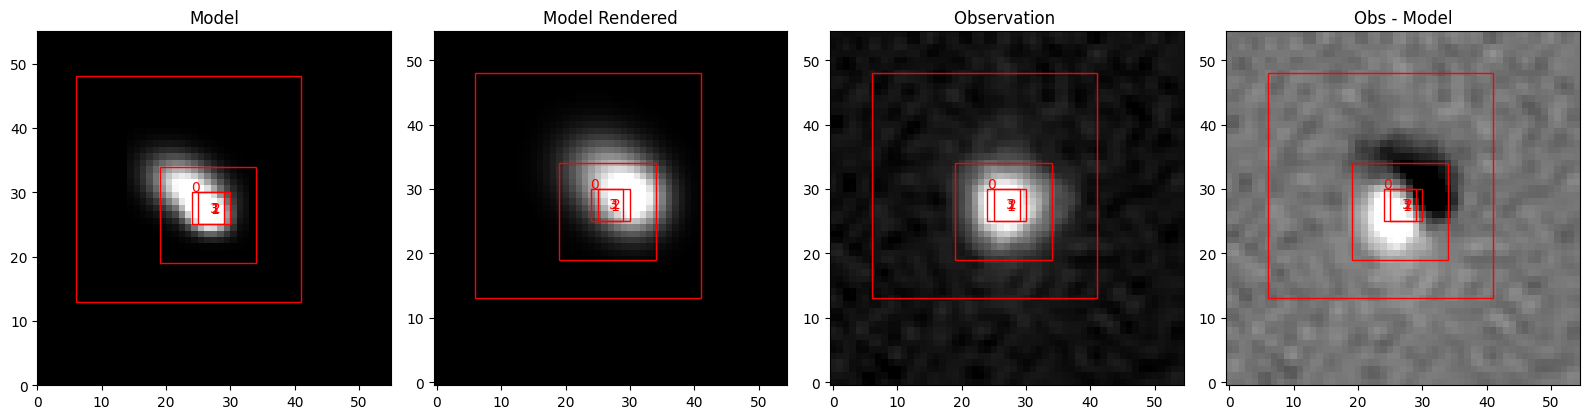

In [83]:
# Plot the model, for each epoch
scarlet2.plot.scene(
    scene,
    observation=observations_sc2[8],
    norm=None,
    show_model=True,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    split_channels=False,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)
save_path = f'{additional_path}{img_index}_results/{date}/roman_off_epoch/sc2_prefitting/'
plt.savefig(save_path+ str(img_index)+'_scene_prefit_lsst'+version+'.png')

plt.show()


### Fitting

In [76]:
pos_step = 5e-3
morph_step = lambda p: scarlet2.relative_step(p, factor=5e-5)
SED_step_SN = lambda p: scarlet2.relative_step(p, factor=5e-3)
SED_step_gal = lambda p: scarlet2.relative_step(p, factor=2e-4)



for i, obs in enumerate(observations_sc2): #[:-n_roman]):
    obs.check_set_renderer(model_frame)
    with scarlet2.Parameters(obs):
        scarlet2.Parameter(obs.renderer[1].shift, name=f"shift_{i}", stepsize=5e-3  * u.arcsec) #5e-2   #1e-2

    
with Parameters(scene):   #as parameters:  --> old syntax
    for source_indx in range(len(scene.sources)):

        if is_extended[source_indx]:
            SED_step = SED_step_gal
        else:
            SED_step = SED_step_SN
            
        scarlet2.Parameter(scene.sources[source_indx].spectrum.data, 
                                         name=f"spectrum.{source_indx}", 
                                         stepsize=SED_step,
                                         constraint=constraints.positive,   
                                        )   #are constrains supposed to be included? no in scarlet2 docs
    
        if is_extended[source_indx]:
            #Static host galaxy parameters; or lens
            scarlet2.Parameter(scene.sources[source_indx].morphology, #morphology.data or morphology.coeffs
                                             name=f"morph.{source_indx}", stepsize=morph_step,
                                             constraint=constraints.positive)#, prior=prior)
            
        else:
            #Transient point source parameters
            scarlet2.Parameter(scene.sources[source_indx].center, 
                               name=f"center.{source_indx}",
                               stepsize=pos_step
                                            )
             
# # set better initial spectra - scale based on your Ie_dict ratios
# # order is [g, r, i, roman_g, roman_r, roman_i]
# host_init_sed = jnp.array([1.57, 3.17, 4.62, 1.57, 3.17, 4.62])  # copy Rubin values as starting point
# lens_init_sed = jnp.array([0.14, 0.27, 0.42, 0.14, 0.27, 0.42])

# object.__setattr__(scene.sources[1].spectrum, 'data', host_init_sed)
# object.__setattr__(scene.sources[0].spectrum, 'data', lens_init_sed) 


In [77]:
print(scene.sources[1].spectrum.data)
print(scene.sources[0].spectrum.data)

[0.18415524 0.2545673  0.24769789 0.68049216 0.2725639  0.01622605]
[0.04444335 0.05645793 0.12834163 0.27292496 0.47856337 0.5284196 ]


In [78]:
for k, src in enumerate(scene.sources):
    print("Source {}, Fluxes: {}".format(k, scarlet2.measure.flux(src)))

Source 0, Fluxes: [ 33.870003  33.870003  33.870003  33.870003  33.870003  33.870003
  33.870003  33.870003  33.870003  33.870003  33.870003  33.870003
  33.870003  33.870003  33.870003  33.870003  43.02624   43.02624
  43.02624   43.02624   43.02624   43.02624   43.02624   43.02624
  43.02624   43.02624   43.02624   43.02624   43.02624   43.02624
  43.02624   43.02624   97.808365  97.808365  97.808365  97.808365
  97.808365  97.808365  97.808365  97.808365  97.808365  97.808365
  97.808365  97.808365  97.808365  97.808365  97.808365  97.808365
 207.99445  364.7102   402.70535 ]
Source 1, Fluxes: [ 44.38546    44.38546    44.38546    44.38546    44.38546    44.38546
  44.38546    44.38546    44.38546    44.38546    44.38546    44.38546
  44.38546    44.38546    44.38546    44.38546    61.356316   61.356316
  61.356316   61.356316   61.356316   61.356316   61.356316   61.356316
  61.356316   61.356316   61.356316   61.356316   61.356316   61.356316
  61.356316   61.356316   59.70065    

In [50]:
# Fit the scene
stepnum = 15000
# scene_ = scene.fit(observations_sc2, parameters, max_iter=stepnum, e_rel=1e-4, progress_bar=True)  #old synatx
scene_, observations_sc2_ = scarlet2.fit(scene, observations_sc2, max_iter=stepnum, e_rel=1e-7, progress_bar=True)   # e_rel = 1e-7


  0%|          | 0/15000 [00:00<?, ?it/s]

In [51]:
# import scarlet2.io as io
# id = int(str(img_index) + '7')
# print(id)
# filename = "scarlet2_caustics_models.h5"
# io.model_to_h5(scene_, filename, id=id, overwrite=True)

In [52]:
# pixel scale in arcsec/pixel
model_pixel_scale = np.sqrt(np.abs(np.linalg.det(scene_.frame.wcs.pixel_scale_matrix))) * 3600

# total width in arcsec
n_pixels = scene_.frame.bbox.shape[-1]  # assuming square
total_width = n_pixels * model_pixel_scale

print(f"Pixel scale: {model_pixel_scale:.4f} arcsec/pixel")
print(f"Total width: {total_width:.4f} arcsec")


source_positions = {}
for i, src in enumerate(scene_.sources):
    theta_x = (src.center[1] * model_pixel_scale) - (total_width / 2)
    theta_y = (src.center[0] * model_pixel_scale) - (total_width / 2)
    source_positions[i] = (theta_x, theta_y)
    print(f"Source {i}: ({theta_x:.4f}, {theta_y:.4f}) arcsec")

# then compute separations between any two sources
for i in range(len(scene_.sources)):
    for j in range(i+1, len(scene_.sources)):
        dx = source_positions[i][0] - source_positions[j][0]
        dy = source_positions[i][1] - source_positions[j][1]
        sep = np.sqrt(dx**2 + dy**2)
        print(f"Separation source {i} -- source {j}: {sep:.4f} arcsec")

Pixel scale: 0.1100 arcsec/pixel
Total width: 6.0500 arcsec
Source 0: (-0.3989, 0.2934) arcsec
Source 1: (-0.0580, -0.0822) arcsec
Source 2: (0.2229, -0.1189) arcsec
Source 3: (-0.4522, -0.3188) arcsec
Separation source 0 -- source 1: 0.5072 arcsec
Separation source 0 -- source 2: 0.7460 arcsec
Separation source 0 -- source 3: 0.6146 arcsec
Separation source 1 -- source 2: 0.2833 arcsec
Separation source 1 -- source 3: 0.4597 arcsec
Separation source 2 -- source 3: 0.7041 arcsec


In [53]:
# using only the Jacobian tranform between the resampled and native HSC frame
# this ignores possible frame offset because the shift is relative
# get the astrometry shift
shift = observations_sc2_[0].get("shift")
print(f"Shift in model pixels: {shift}")

for i, obs in enumerate(observations_sc2): #[:-n_roman]):

    shift_band = observations_sc2_[i].get(f"shift_{i}")
    print(f"Obs {i}  shift in model pixels: {shift_band}")
    
    obs = observations_sc2[i]
    obs_ = observations_sc2_[i]

    jacobian, _ = scarlet2.frame.get_relative_jacobian_shift(obs_.frame, obs.frame)
    shift_native = jacobian @ shift_band
    # print(f"{i}: Shift in native pixels: {shift_native}")
    
    # create the renderer for native HSC if not already there
    obs.check_set_renderer(model_frame)
    # force the renderer to use optimized value for shift
    object.__setattr__(obs.renderer[-1], "shift", shift_native)
    



Shift in model pixels: None
Obs 0  shift in model pixels: [0.83623564 3.8314    ]
Obs 1  shift in model pixels: [0.7707703 3.8830392]
Obs 2  shift in model pixels: [0.77174157 3.6156604 ]
Obs 3  shift in model pixels: [0.74106777 3.4604268 ]
Obs 4  shift in model pixels: [0.7075104 3.3245673]
Obs 5  shift in model pixels: [0.7149493 3.058674 ]
Obs 6  shift in model pixels: [0.6110014 2.955284 ]
Obs 7  shift in model pixels: [0.62200606 2.8796937 ]
Obs 8  shift in model pixels: [0.6775213 3.0570378]
Obs 9  shift in model pixels: [0.6462361 3.235165 ]
Obs 10  shift in model pixels: [0.76060176 3.3217435 ]
Obs 11  shift in model pixels: [0.7779406 3.6591835]
Obs 12  shift in model pixels: [0.9182982 3.7705374]
Obs 13  shift in model pixels: [0.727226 3.85748 ]
Obs 14  shift in model pixels: [0.8963748 3.9531562]
Obs 15  shift in model pixels: [1.0169957 3.8253102]
Obs 16  shift in model pixels: [1.2801352 3.771115 ]
Obs 17  shift in model pixels: [1.2090383 3.8304722]
Obs 18  shift in mod

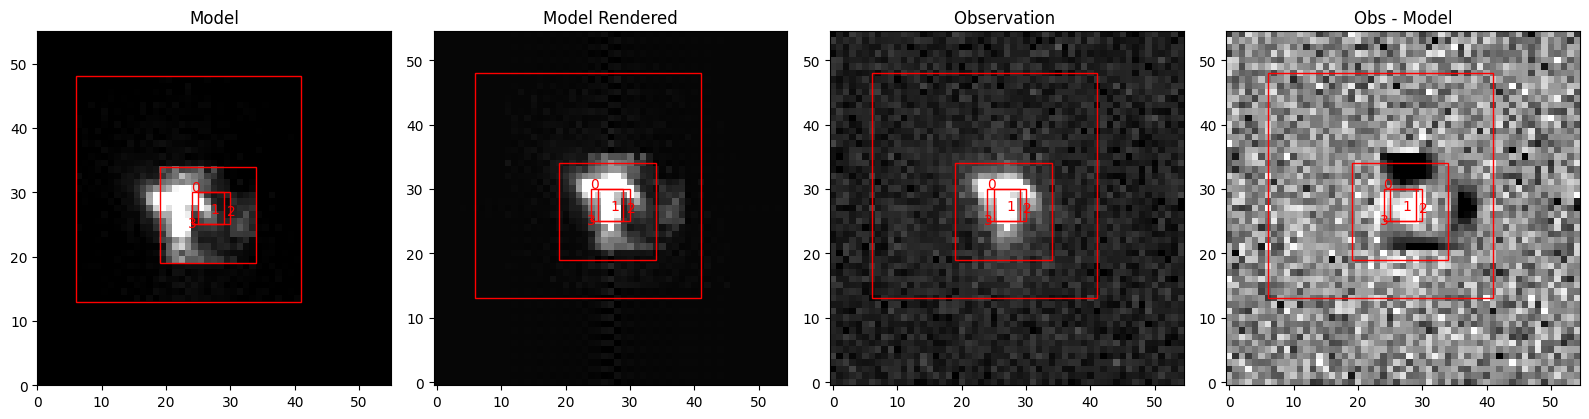

In [59]:
scarlet2.plot.scene(
    scene_,
    observation=observations_sc2[48],
    show_rendered=True,
    show_observed=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    norm=None,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)

save_path = f'{additional_path}{img_index}_results/{date}/roman_off_epoch/sc2_postfitting/'
plt.savefig(save_path+str(img_index)+'_postfit_roman_'+str(BANDS[0])+'_0'+version+'.png')

plt.show()


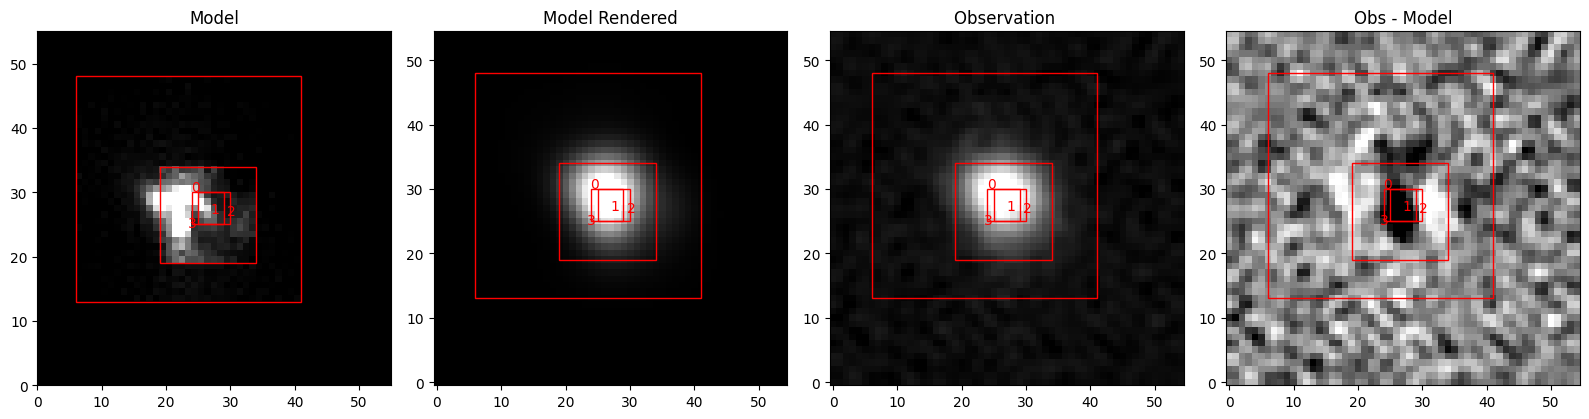

In [65]:
scarlet2.plot.scene(
    scene_,
    observation=observations_sc2[32],
    show_rendered=True,
    show_observed=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    norm=None,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)

save_path = f'{additional_path}{img_index}_results/{date}/roman_off_epoch/sc2_postfitting/'
plt.savefig(save_path+str(img_index)+'_postfit_lsst_'+str(bands[2])+'_0'+version+'.png')

plt.show()


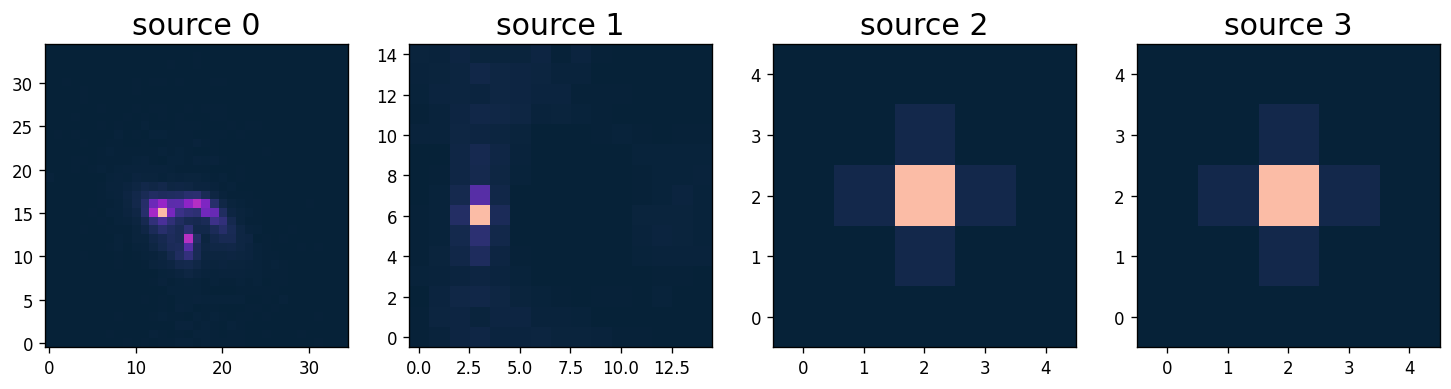

<Figure size 640x480 with 0 Axes>

In [66]:
cmap = cmr.bubblegum
int_method='none'
fig, axes = plt.subplots(1, len( scene_.sources ), figsize=(15,6),dpi=120)
for i, ax in enumerate(axes):
    if is_extended[i]==True:#i!=indtransient:
        y = np.array(scene_.sources[i].morphology)  # should work if it's already 2D or 3D
    else:
        y = scene_.sources[i].morphology()
    ax.imshow(y, cmap = cmap,interpolation=int_method)#,vmin = np.max([np.min(np.log(y)[np.log(y)>-15]),-15]))
    ax.set_title(f"source {i}", fontsize = 18)
    # ax.invert_yaxis()

save_path = f'{additional_path}{img_index}_results/{date}/roman_off_epoch/sc2_postfitting/'
plt.savefig(save_path+str(img_index)+'_source_models_postfit'+version+'.png')

plt.show()
plt.clf()

In [67]:
for k, src in enumerate(scene_.sources):
    print("Source {}, Fluxes: {}".format(k, scarlet2.measure.flux(src)))

Source 0, Fluxes: [ 33.870003  33.870003  33.870003  33.870003  33.870003  33.870003
  33.870003  33.870003  33.870003  33.870003  33.870003  33.870003
  33.870003  33.870003  33.870003  33.870003  43.02624   43.02624
  43.02624   43.02624   43.02624   43.02624   43.02624   43.02624
  43.02624   43.02624   43.02624   43.02624   43.02624   43.02624
  43.02624   43.02624   97.808365  97.808365  97.808365  97.808365
  97.808365  97.808365  97.808365  97.808365  97.808365  97.808365
  97.808365  97.808365  97.808365  97.808365  97.808365  97.808365
 207.99445  364.7102   402.70535 ]
Source 1, Fluxes: [ 44.38546    44.38546    44.38546    44.38546    44.38546    44.38546
  44.38546    44.38546    44.38546    44.38546    44.38546    44.38546
  44.38546    44.38546    44.38546    44.38546    61.356316   61.356316
  61.356316   61.356316   61.356316   61.356316   61.356316   61.356316
  61.356316   61.356316   61.356316   61.356316   61.356316   61.356316
  61.356316   61.356316   59.70065    

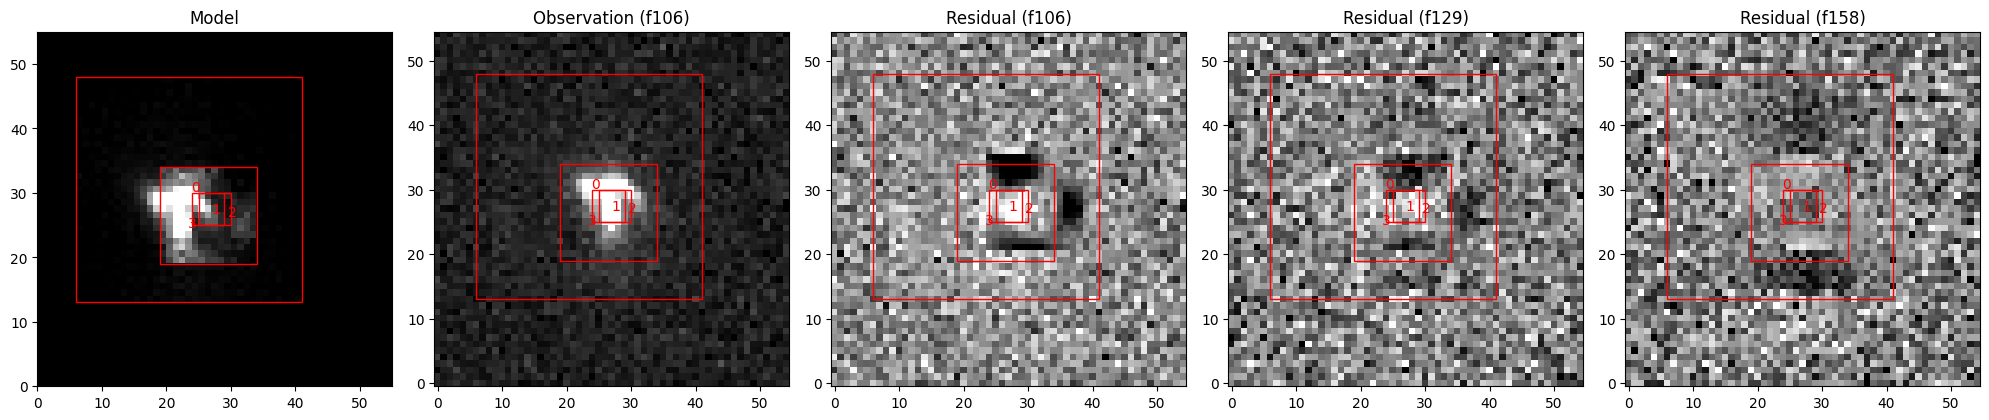

In [86]:
from scarlet2.plot import ChannelRenderer, img_to_rgb, LinearPercentileNorm
from matplotlib.patches import Polygon


telescope = 'roman'
epoch = 0

if telescope == 'lsst':
    band_name = [bands[0], bands[1], bands[2]]
    if epoch == 0:
        epoch_idx = [0, 16, 32]
    elif epoch ==8:
        epoch_idx = [8, 24, 40]
elif telescope == 'roman':
    band_name = [BANDS[0], BANDS[1], BANDS[2]]
    if epoch == 0:
        epoch_idx = [48, 49, 50]
    elif epoch ==8:
        epoch_idx = [51, 51, 53]

subplot_specs = [
    {"type": "model",    "scene": scene_, "observation": observations_sc2[epoch_idx[0]]},
    {"type": "observed", "scene": scene_, "observation": observations_sc2[epoch_idx[0]], "title": f"Observation ({band_name[0]})"},
    {"type": "residual", "scene": scene_, "observation": observations_sc2[epoch_idx[0]], "title": f"Residual ({band_name[0]})"},
    {"type": "residual", "scene": scene_, "observation": observations_sc2[epoch_idx[1]], "title": f"Residual ({band_name[1]})"},
    {"type": "residual", "scene": scene_, "observation": observations_sc2[epoch_idx[2]], "title": f"Residual ({band_name[2]})"},
]

norm         = None
channel_map  = None
add_labels   = True
add_boxes    = True
title_kwargs = {}
label_kwargs = {"color": "red"}
box_kwargs   = {"facecolor": "none", "edgecolor": "red"}
panel_size = 4  # inches per panel, adjust as needed

panels  = len(subplot_specs)
fig, ax = plt.subplots(1, panels, figsize=(panel_size * panels, panel_size), squeeze=False)

for panel, spec in enumerate(subplot_specs):
    ptype        = spec["type"]
    scene        = spec["scene"]
    observation  = spec.get("observation", None)
    custom_title = spec.get("title", None)
    model        = scene()

    if ptype == "model":
        if observation is not None:
            c = ChannelRenderer(scene.frame, observation.frame)
            display = c(model)
        else:
            display = model
        extent = scene.frame.bbox.get_extent()
        ax[0, panel].imshow(img_to_rgb(display, norm=norm, channel_map=channel_map), extent=extent, origin="lower")
        ax[0, panel].set_title(custom_title or "Model")

    elif ptype == "rendered":
        observation.check_set_renderer(scene.frame)
        model_rendered = observation.render(model)
        ax[0, panel].imshow(img_to_rgb(model_rendered, norm=norm, channel_map=channel_map), origin="lower")
        ax[0, panel].set_title(custom_title or "Model Rendered")

    elif ptype == "observed":
        data  = observation.data
        mask  = observation.weights == 0
        mask_ = np.sum(mask, axis=0) > 0
        mask_ = None if np.all(mask_ == 0) else mask_
        ax[0, panel].imshow(img_to_rgb(data, norm=norm, channel_map=channel_map, mask=mask_), origin="lower")
        ax[0, panel].set_title(custom_title or "Observation")

    elif ptype == "residual":
        observation.check_set_renderer(scene.frame)
        model_rendered = observation.render(model)
        data  = observation.data
        mask  = observation.weights == 0
        mask_ = np.sum(mask, axis=0) > 0
        mask_ = None if np.all(mask_ == 0) else mask_
        residual = data - model_rendered
        norm_    = LinearPercentileNorm(residual)
        ax[0, panel].imshow(img_to_rgb(residual, norm=norm_, channel_map=channel_map, mask=mask_), origin="lower")
        ax[0, panel].set_title(custom_title or "Obs - Model")

    for k, src in enumerate(scene.sources):
        if add_boxes:
            start, stop = src.bbox.spatial.start, src.bbox.spatial.stop
            corners = jnp.array([start, jnp.array((start[0], stop[1])), stop, jnp.array((stop[0], start[1]))])
            corners_ = observation.frame.get_pixel(scene.frame.get_sky_coord(corners))
            poly = Polygon(corners_[:, ::-1], closed=True, **box_kwargs)
            ax[0, panel].add_artist(poly)
        if add_labels:
            center  = src.center
            center_ = observation.frame.get_pixel(scene.frame.get_sky_coord(center)).flatten()
            ax[0, panel].text(*(center_[::-1]), k, **label_kwargs)

fig.tight_layout()

save_path = f'{additional_path}{img_index}_results/{date}/roman_off_epoch/sc2_postfitting/'
plt.savefig(f'{save_path}{str(img_index)}_postfit_{telescope}_band_comparison_{epoch}{version}.png')

plt.show()


## Save SN fluxes

In [71]:
import pickle


# Define Rubin bands of interest
rubin_bands = ['g', 'r', 'i']

# Get indices of (band, epoch) for each Rubin band
band_epoch_indices = {band: [] for band in rubin_bands}
for idx, (band, epoch) in enumerate(channels):
    if band in rubin_bands:
        band_epoch_indices[band].append((int(epoch), idx))

# Get indices of point sources (is_extended == False)
point_source_indices = [i for i, ext in enumerate(is_extended) if not ext]
num_point_sources = len(point_source_indices)

# Determine the number of epochs per band
max_epochs = {
    band: max(epoch for epoch, _ in indices) + 1
    for band, indices in band_epoch_indices.items()
}

# Initialize output flux structure: bands × epochs × sources
flux_array = {
    band: [[0.0 for _ in range(num_point_sources)] for _ in range(max_epochs[band])]
    for band in rubin_bands
}

# Fill in the flux values for only point sources
for local_idx, src_idx in enumerate(point_source_indices):
    fluxes = scarlet2.measure.flux(scene_.sources[src_idx])
    for band in rubin_bands:
        for epoch, flux_idx in band_epoch_indices[band]:
            flux_array[band][epoch][local_idx] = fluxes[flux_idx]

# Convert to final nested array format
output_array = [flux_array[band] for band in rubin_bands]

print(output_array)

# Save to file
file_path = 'fluxes_files/scarlet_deblended_flux/'
with open(file_path+'rubin_scarlet_caustics_fluxes_'+str(img_index)+str(version)+'.pkl', "wb") as f:
    pickle.dump(output_array, f)

#save txt with times used
# np.savetxt(f"rubin_scarlet_caustics_times_{img_index}{version}.txt", times, fmt="%.6f")
print(f"Saved times array to rubin_times_{img_index}{version}.txt")

[[[Array(0., dtype=float32), Array(0., dtype=float32)], [Array(4.1626024, dtype=float32), Array(0.53782094, dtype=float32)], [Array(28.476475, dtype=float32), Array(1.5543267, dtype=float32)], [Array(39.24551, dtype=float32), Array(3.2150393, dtype=float32)], [Array(27.74393, dtype=float32), Array(11.008671, dtype=float32)], [Array(21.093632, dtype=float32), Array(18.837164, dtype=float32)], [Array(14.371243, dtype=float32), Array(22.9028, dtype=float32)], [Array(10.621464, dtype=float32), Array(22.856653, dtype=float32)], [Array(8.287644, dtype=float32), Array(21.628492, dtype=float32)], [Array(5.519724, dtype=float32), Array(15.377012, dtype=float32)], [Array(3.9143538, dtype=float32), Array(12.783528, dtype=float32)], [Array(2.1405063, dtype=float32), Array(5.4164762, dtype=float32)], [Array(1.3099165, dtype=float32), Array(3.38098, dtype=float32)], [Array(5.3253857e-06, dtype=float32), Array(1.2075659, dtype=float32)], [Array(0., dtype=float32), Array(0., dtype=float32)], [Array(0.

In [72]:
print(np.array(output_array)[2].shape)

(16, 2)


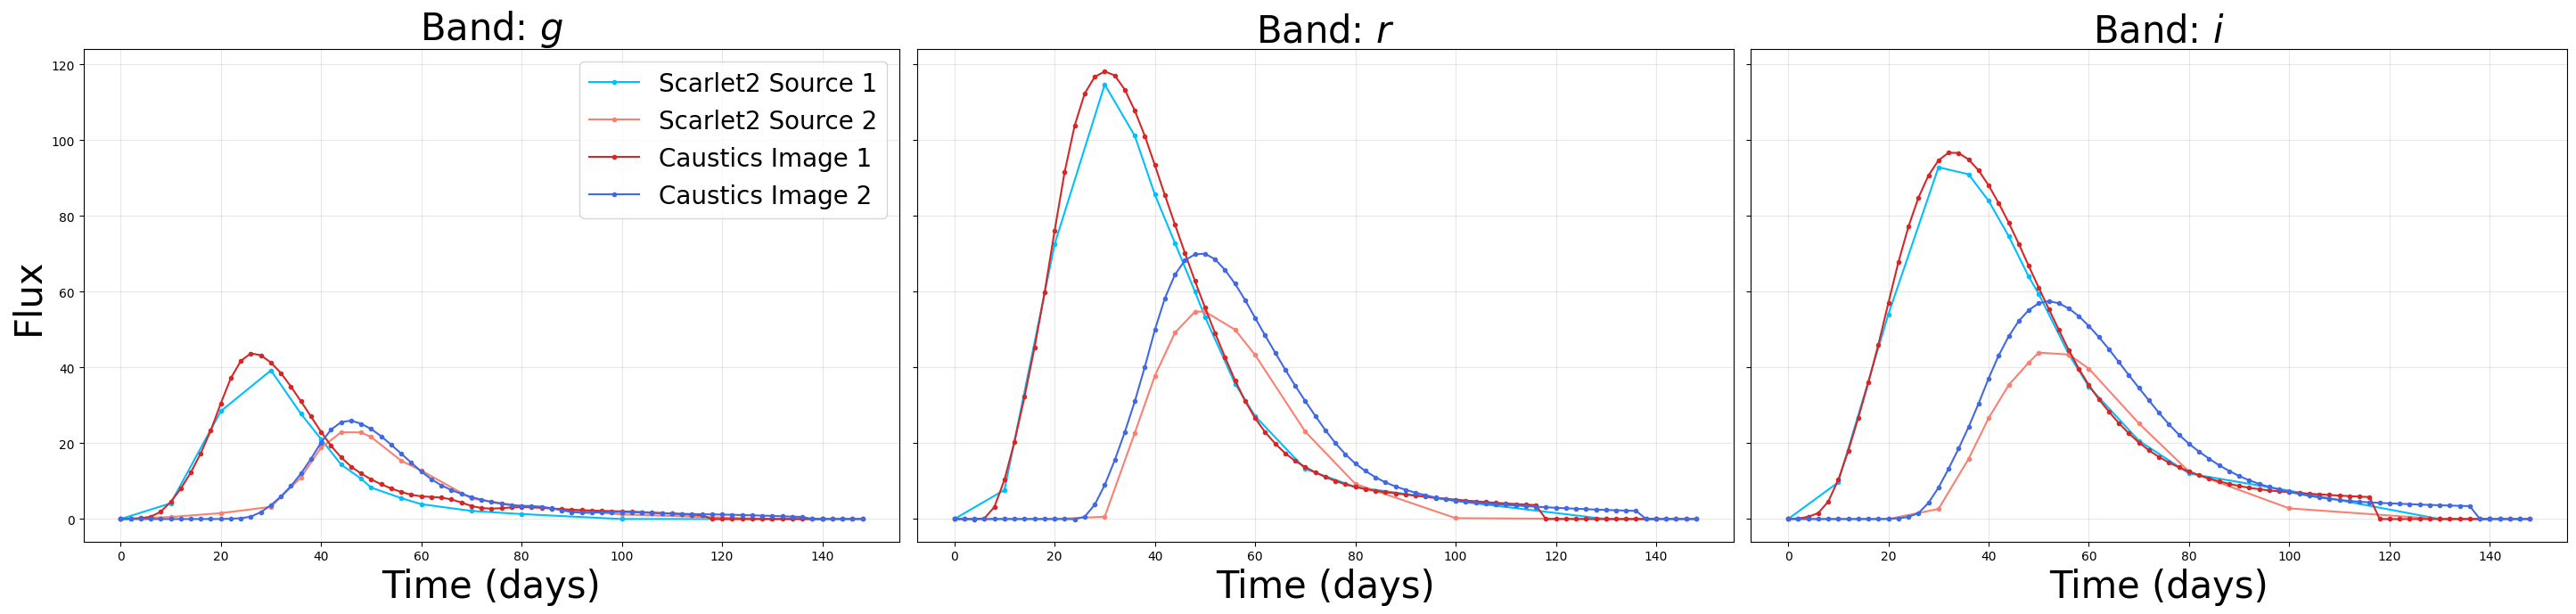

In [73]:
import pickle

with open('fluxes_files/caustics_flux/caustics_fluxes_'+str(img_index)+'_14_04_26'+'.pkl', "rb") as caustics_f:
    caustics_fluxes = pickle.load(caustics_f)
caustics_times = np.arange(0, 150, 2) 

sc_times = [0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140]


fig, axes = plt.subplots(1, 3, figsize=(29, 7), sharey=True)
caustics_colors = ['tab:red', 'royalblue']
sc_colors = ['deepskyblue', 'salmon']
band_names_plot = [r'$g$', r'$r$', r'$i$']

for band_indx, band in enumerate(rubin_bands):
    ax = axes[band_indx]
    n_caustics_epochs = len(caustics_fluxes[band_indx])
    sc_epochs = sorted(set(epoch for epoch, _ in band_epoch_indices[band]))

    for local_idx in range(num_point_sources):
        sc_flux = np.array([flux_array[band][epoch][local_idx] for epoch in sc_epochs])
        ax.plot(sc_times, sc_flux, marker='o', markersize=3,
                label=f'Scarlet2 Source {local_idx+1}', color=sc_colors[local_idx])

    for local_idx in range(num_point_sources):
        caustics_flux = np.array([caustics_fluxes[band_indx][t][num_point_sources - 1 - local_idx]
                                  for t in range(n_caustics_epochs)])
        ax.plot(caustics_times, caustics_flux, marker='o', markersize=3,
                label=f'Caustics Image {local_idx+1}', color=caustics_colors[local_idx])

    ax.set_title(f'Band: {band_names_plot[band_indx]}', fontsize=30)
    ax.set_xlabel('Time (days)', fontsize=30)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Flux', fontsize=30)
axes[0].legend(loc='upper right', fontsize=20)
# fig.suptitle('System ' + str(img_index) + r', $\Delta t = $' + td, fontsize=30)
plt.tight_layout()
plt.show()

## Get variance of residuals

In [75]:
# --- Setup indices (Same as before) ---
rubin_bands = ['g', 'r', 'i'] 

# Point sources only
point_source_indices = [i for i, ext in enumerate(is_extended) if not ext]

# Map (band, epoch) -> channel index
band_epoch_indices = {band: [] for band in rubin_bands}
for ch_idx, (band, epoch) in enumerate(channels):
    if band in rubin_bands:
        band_epoch_indices[band].append((int(epoch), ch_idx))

max_epochs = {
    band: max(e for e, _ in idxs) + 1 if idxs else 0
    for band, idxs in band_epoch_indices.items()
}

def compute_flux_error_array(scene, observations, point_source_indices,
                             rubin_bands, channels, max_epochs):
    
    # Initialize: bands × epochs × sources
    err_array = {
        band: [[0.0 for _ in range(len(point_source_indices))]
               for _ in range(max_epochs[band])]
        for band in rubin_bands
    }

    # Generate the model once
    model = scene()

    # --- FIX: Loop over the observations list directly ---
    # Assuming 'observations' list aligns with 'channels' list 1-to-1
    for ch_idx, obs in enumerate(observations):
        
        # Get metadata for this specific observation
        band, epoch = channels[ch_idx]
        epoch = int(epoch)
        
        # Skip if not a band we care about
        if band not in rubin_bands:
            continue

        # 1. Render and Compute Residual for THIS observation
        try:
            model_rendered = obs.render(model)
            residual = obs.data - model_rendered
            # Note: obs.data usually (C, Y, X). For single obs, C=0 often.
            
            # If residual is (1, Y, X), grab the 2D image
            if residual.ndim == 3:
                residual_img = residual[0]
                if hasattr(obs, "weights"):
                    weight_img = obs.weights[0]
                else:
                    weight_img = np.ones_like(residual_img)
            else:
                residual_img = residual
                weight_img = np.ones_like(residual)

            ny, nx = residual_img.shape

            # 2. Loop over sources to measure variance in this specific frame
            for local_idx, src_idx in enumerate(point_source_indices):
                src = scene.sources[src_idx]

                # -- Bounding Box Logic --
                start, stop = src.bbox.spatial.start, src.bbox.spatial.stop
                
                # Create corners in Model Frame
                corners = jnp.array([
                    start,
                    jnp.array((start[0], stop[1])),
                    stop,
                    jnp.array((stop[0], start[1])),
                ])
                
                # Transform corners to Observation Frame (Pixel coordinates)
                corners_obs = obs.frame.get_pixel(scene.frame.get_sky_coord(corners))
                ys = np.array(corners_obs[:, 0])
                xs = np.array(corners_obs[:, 1])

                # Get integer bounds
                y0, y1 = int(np.floor(ys.min())), int(np.ceil(ys.max()))
                x0, x1 = int(np.floor(xs.min())), int(np.ceil(xs.max()))

                # Clip to image bounds
                y0 = max(0, y0); y1 = min(ny, y1)
                x0 = max(0, x0); x1 = min(nx, x1)

                # Check if source is valid in this frame
                if y1 <= y0 or x1 <= x0:
                    err_array[band][epoch][local_idx] = 1e10
                    continue

                # Extract cutout
                patch = np.array(residual_img[y0:y1, x0:x1])
                w_patch = np.array(weight_img[y0:y1, x0:x1])

                # Filter for valid pixels
                valid_pixels = patch[w_patch > 0]

                if valid_pixels.size == 0:
                    flux_err = 1e10
                else:
                    # 1) Variance per pixel
                    pixel_var = np.var(valid_pixels)
                    
                    # 2) Flux Error = sqrt(N * sigma^2)
                    # N should be the number of valid pixels contributing to the sum
                    N = valid_pixels.size
                    flux_err = float(np.sqrt(N * pixel_var))

                err_array[band][epoch][local_idx] = flux_err

        except Exception as e:
            print(f"Error processing obs {ch_idx} ({band} {epoch}): {e}")
            # Fill defaults for this whole epoch if render fails
            for local_idx in range(len(point_source_indices)):
                err_array[band][epoch][local_idx] = 1e10

    # Reformat dictionary to list
    final_error_array = [err_array[band] for band in rubin_bands]
    return final_error_array

# --- Execution ---
error_array = compute_flux_error_array(
    scene_,
    observations_sc2, # Pass the full list
    point_source_indices,
    rubin_bands,
    channels,         # Pass channels to map list index to band/epoch
    max_epochs
)

file_path = 'fluxes_files/scarlet_deblended_flux_errors/'
with open(f"{file_path}rubin_scarlet_caustics_errors_{img_index}{version}.pkl", "wb") as f:
    pickle.dump(error_array, f)

print("Saved flux errors.")

Saved flux errors.
